In [8]:
import pandas as pd

# Load the Excel file object to inspect its sheets
excel_file = pd.ExcelFile('/content/EastWestAirlines.xlsx')

# Print all sheet names in the Excel file
print(f"Sheets in the Excel file: {excel_file.sheet_names}")

# Load the 'data' sheet explicitly, as indicated by the sheet names
df = pd.read_excel('/content/EastWestAirlines.xlsx', sheet_name='data')

# Drop the 'ID#' column as it's an identifier and not relevant for clustering
df = df.drop('ID#', axis=1)

# Display the first 5 rows of the DataFrame after dropping 'ID#'
display(df.head())

Sheets in the Excel file: ['Description', 'data']


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [9]:
# Get a concise summary of the DataFrame, including data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            3999 non-null   int64
 1   Qual_miles         3999 non-null   int64
 2   cc1_miles          3999 non-null   int64
 3   cc2_miles          3999 non-null   int64
 4   cc3_miles          3999 non-null   int64
 5   Bonus_miles        3999 non-null   int64
 6   Bonus_trans        3999 non-null   int64
 7   Flight_miles_12mo  3999 non-null   int64
 8   Flight_trans_12    3999 non-null   int64
 9   Days_since_enroll  3999 non-null   int64
 10  Award?             3999 non-null   int64
dtypes: int64(11)
memory usage: 343.8 KB


None

In [14]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


First 5 rows of the scaled DataFrame:


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,-0.766919
1,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,-0.766919
2,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,-0.766919
3,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,-0.766919
4,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1.303918


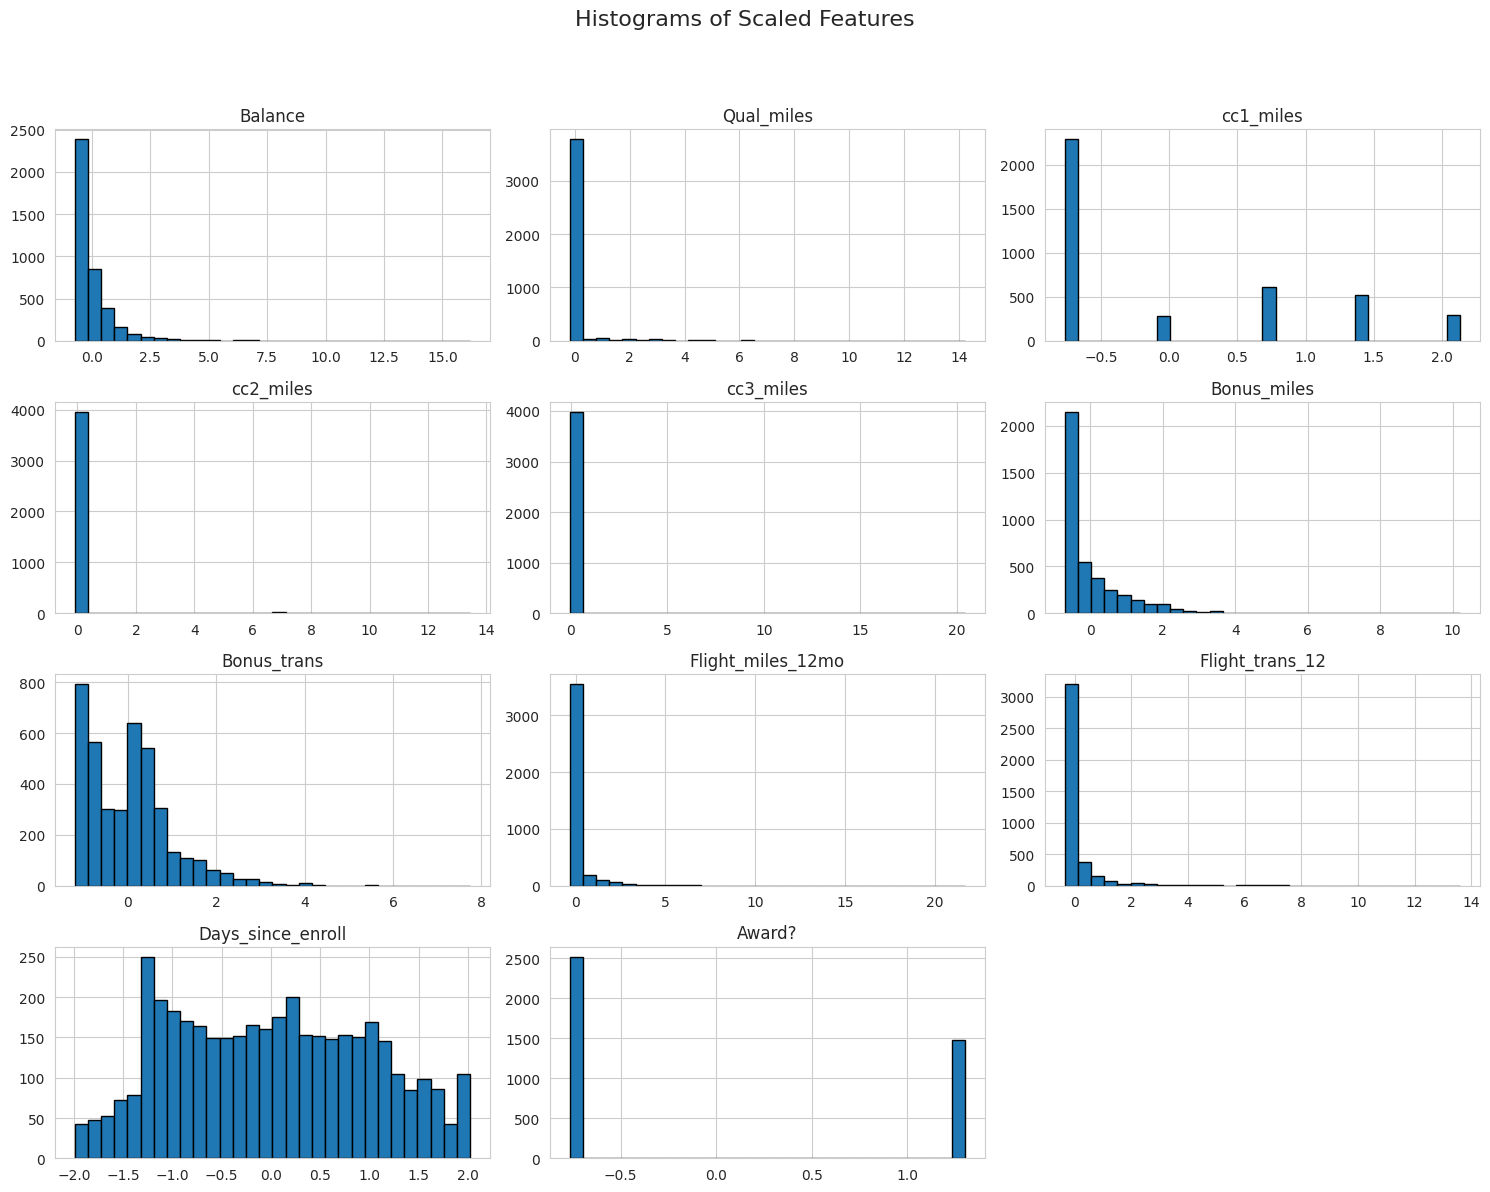

In [15]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the entire DataFrame
# The fit_transform method fits the scaler to the data and then transforms it.
scaled_df = scaler.fit_transform(df)

# Convert the scaled array back to a DataFrame for easier inspection
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)

# Display the first 5 rows of the scaled DataFrame
print("First 5 rows of the scaled DataFrame:")
display(scaled_df.head())

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create histograms for all features in the scaled DataFrame
scaled_df.hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle('Histograms of Scaled Features', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Descriptive statistics of the scaled DataFrame:


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3.999000e+03,3.999000e+03,3.999000e+03,3.999000e+03,3.999000e+03,3.999000e+03,3999.000000,3.999000e+03,3.999000e+03,3.999000e+03
mean,2.842882e-17,6.574164e-17,1.705729e-16,3.038330e-16,1.350369e-16,-2.842882e-17,-7.817925e-17,0.000000,1.776801e-17,5.685763e-17,1.421441e-17
std,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125,1.000125e+00,1.000125e+00,1.000125e+00
min,-7.304396e-01,-1.862987e-01,-7.695784e-01,-9.824189e-02,-6.276658e-02,-7.099918e-01,-1.208203e+00,-0.328603,-3.621679e-01,-1.993611e+00,-7.669193e-01
25%,-5.465676e-01,-1.862987e-01,-7.695784e-01,-9.824189e-02,-6.276658e-02,-6.582276e-01,-8.957878e-01,-0.328603,-3.621679e-01,-8.661823e-01,-7.669193e-01
50%,-3.027332e-01,-1.862987e-01,-7.695784e-01,-9.824189e-02,-6.276658e-02,-4.130308e-01,4.145743e-02,-0.328603,-3.621679e-01,-1.092530e-02,-7.669193e-01
75%,1.866028e-01,-1.862987e-01,6.831212e-01,-9.824189e-02,-6.276658e-02,2.756198e-01,5.621492e-01,-0.106466,-9.850333e-02,8.097050e-01,1.303918e+00
max,1.618884e+01,1.422486e+01,2.135821e+00,1.344898e+01,2.042732e+01,1.020957e+01,7.747696e+00,21.683004,1.361205e+01,2.023095e+00,1.303918e+00


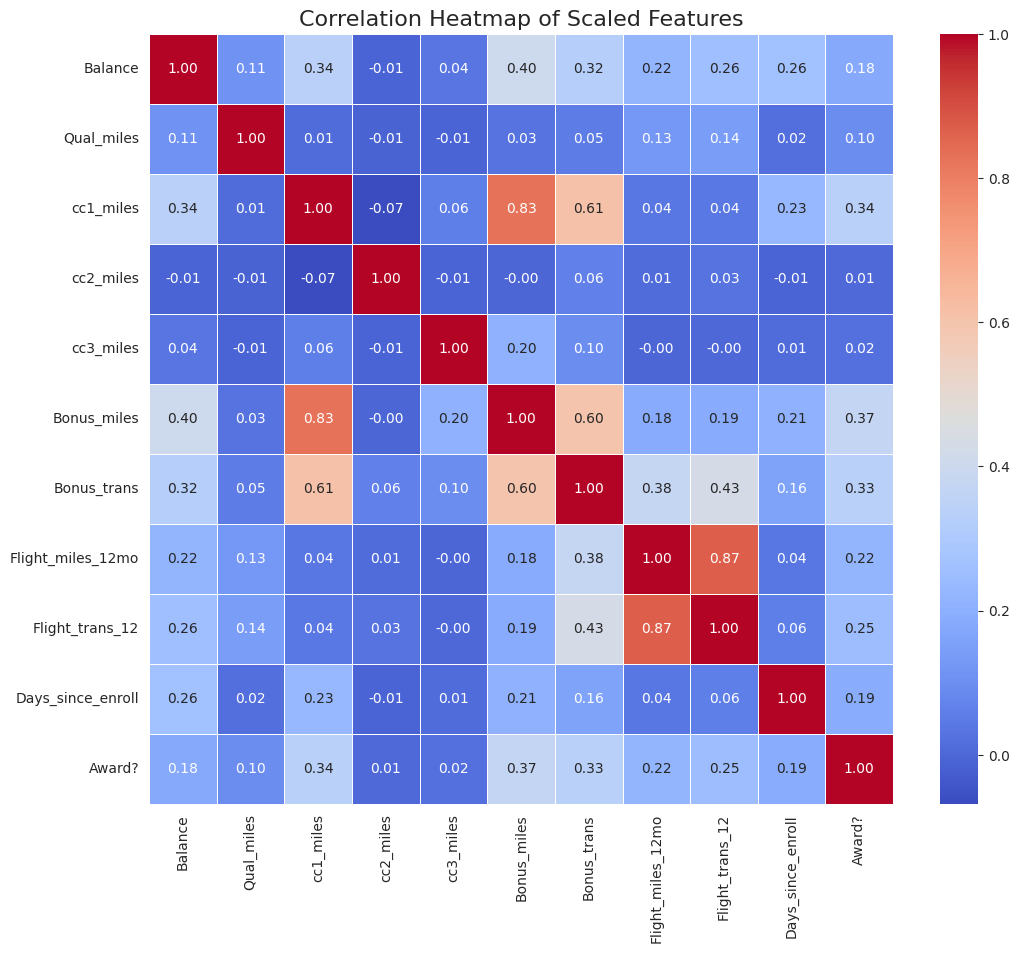

In [16]:
# Display descriptive statistics for the scaled DataFrame
print("Descriptive statistics of the scaled DataFrame:")
display(scaled_df.describe())

# Calculate the correlation matrix
corr_matrix = scaled_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Scaled Features', fontsize=16)
plt.show()

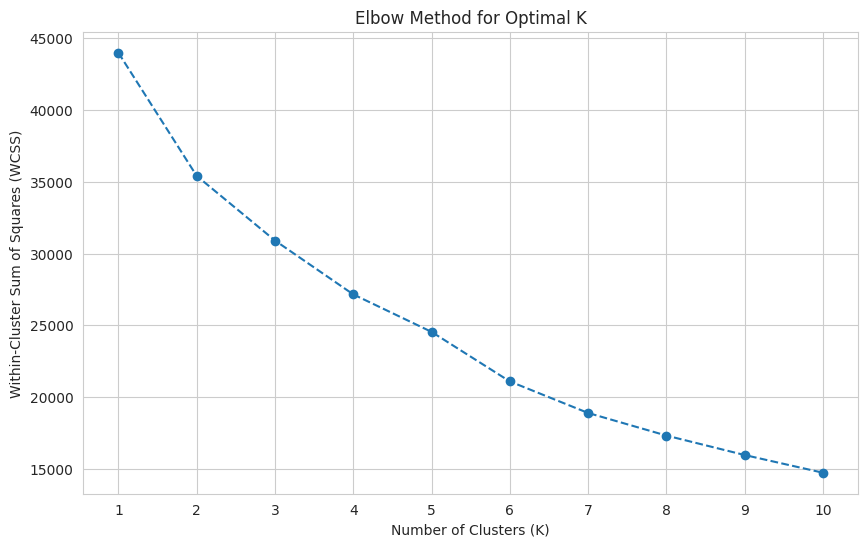

In [17]:
from sklearn.cluster import KMeans

wcss = []
# We'll try K values from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

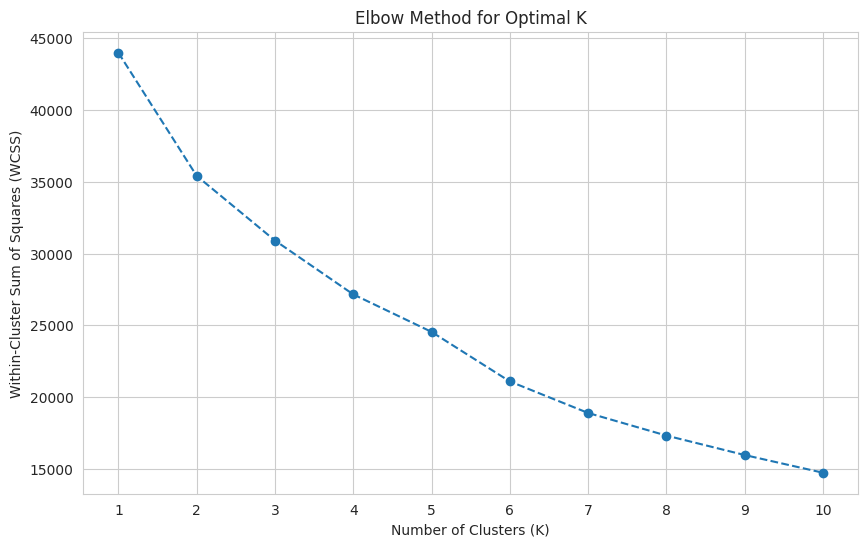

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# We'll try K values from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# K-Means Clustering
# Initialize KMeans with the chosen number of clusters (K=4)
k_value = 4
kmeans_model = KMeans(n_clusters=k_value, init='k-means++', random_state=42, n_init=10)

# Fit the model and predict the clusters
clusters_kmeans = kmeans_model.fit_predict(scaled_df)

# Add the cluster assignments to the original (unscaled) DataFrame
df_clustered_kmeans = df.copy()
df_clustered_kmeans['KMeans_Cluster'] = clusters_kmeans

# Calculate the Silhouette Score
sil_score_kmeans = silhouette_score(scaled_df, clusters_kmeans)
print(f"K-Means Silhouette Score (K={k_value}): {sil_score_kmeans:.4f}")

# Display the count of data points per cluster
print("\nK-Means Cluster Distribution:")
display(df_clustered_kmeans['KMeans_Cluster'].value_counts().sort_index())

# Hierarchical Clustering
# Perform AgglomerativeClustering with n_clusters=4
hc_model = AgglomerativeClustering(n_clusters=4, linkage='ward') # Removed affinity='euclidean'
clusters_hc = hc_model.fit_predict(scaled_df)

# Add the cluster assignments to the original (unscaled) DataFrame
df_clustered_hc = df.copy()
df_clustered_hc['HC_Cluster'] = clusters_hc

# Calculate the Silhouette Score for Hierarchical Clustering
sil_score_hc = silhouette_score(scaled_df, clusters_hc)
print(f"\nHierarchical Clustering Silhouette Score (K=4): {sil_score_hc:.4f}")

# Display the count of data points per cluster
print("\nHierarchical Clustering Cluster Distribution:")
display(df_clustered_hc['HC_Cluster'].value_counts().sort_index())

K-Means Silhouette Score (K=4): 0.3092

K-Means Cluster Distribution:


,count
KMeans_Cluster,
0,15
1,2543
2,1273
3,168



Hierarchical Clustering Silhouette Score (K=4): 0.3081

Hierarchical Clustering Cluster Distribution:


,count
HC_Cluster,
0,1380
1,2446
2,130
3,43


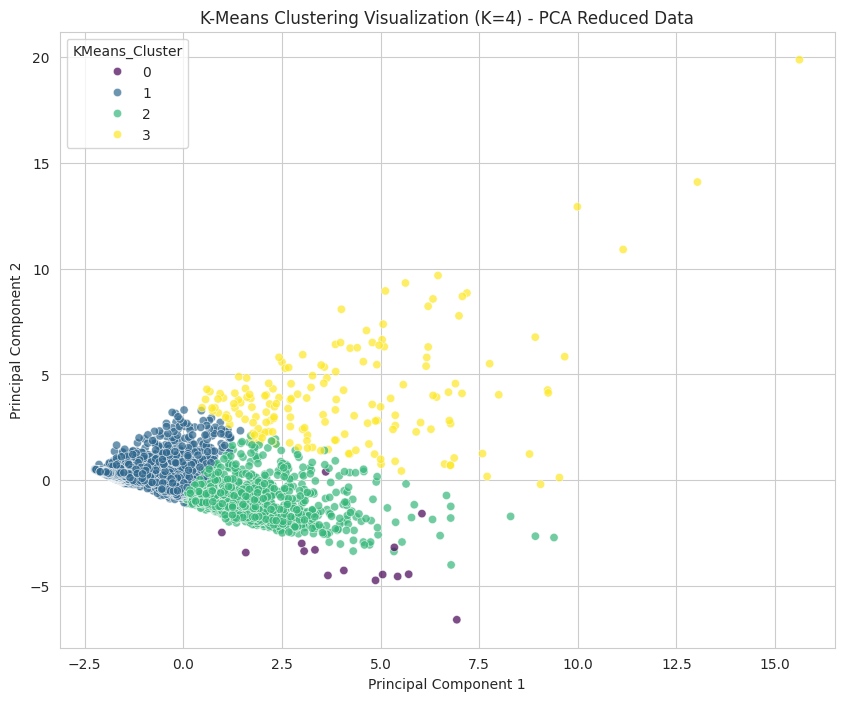

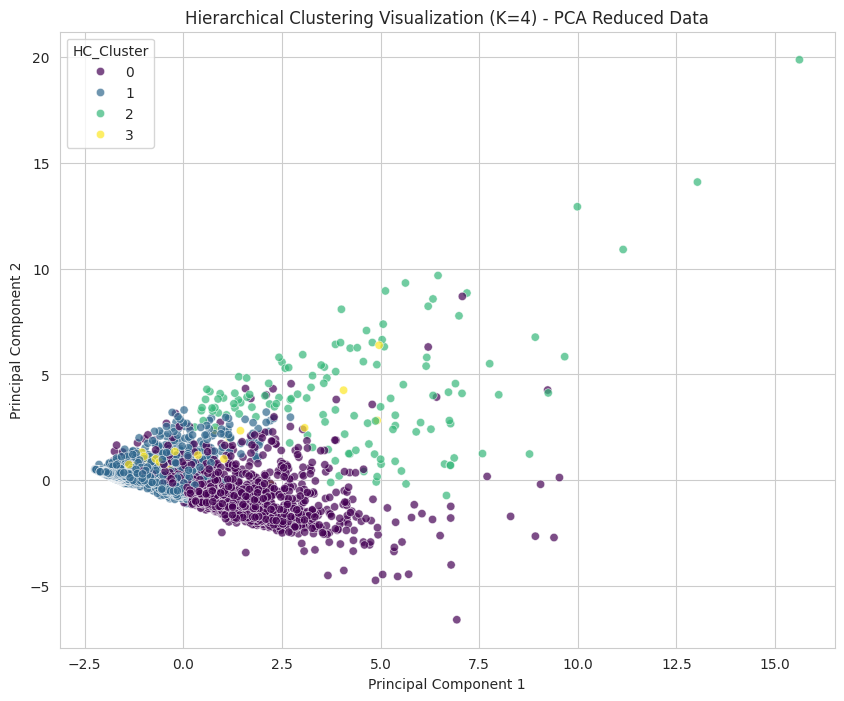

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# K-Means Visualization
# For visualization, reduce dimensions using PCA to 2 components
pca = PCA(n_components=2)
df_pca = pca.fit_transform(scaled_df)

# Create a DataFrame for the PCA results with cluster labels
df_pca_kmeans = pd.DataFrame(data=df_pca, columns=['PCA1', 'PCA2'])
df_pca_kmeans['KMeans_Cluster'] = clusters_kmeans

# Plot the K-Means clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='KMeans_Cluster',
    data=df_pca_kmeans,
    palette='viridis',
    legend='full',
    alpha=0.7
)
plt.title(f'K-Means Clustering Visualization (K={k_value}) - PCA Reduced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# Hierarchical Clustering Visualization
# Create a DataFrame for the PCA results with hierarchical cluster labels
df_pca_hc = pd.DataFrame(data=df_pca, columns=['PCA1', 'PCA2'])
df_pca_hc['HC_Cluster'] = clusters_hc

# Plot the Hierarchical clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='HC_Cluster',
    data=df_pca_hc,
    palette='viridis',
    legend='full',
    alpha=0.7
)
plt.title('Hierarchical Clustering Visualization (K=4) - PCA Reduced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [32]:
# Analyze the characteristics of each K-Means cluster
print("\nK-Means Cluster Characteristics (Mean Values):")
display(df_clustered_kmeans.groupby('KMeans_Cluster').mean())

# Analyze the characteristics of each Hierarchical cluster
print("\nHierarchical Clustering Cluster Characteristics (Mean Values):")
display(df_clustered_hc.groupby('HC_Cluster').mean())


K-Means Cluster Characteristics (Mean Values):


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_Cluster,,,,,,,,,,,
0,138061.400000,78.800000,3.466667,1.000000,4.066667,93927.866667,28.066667,506.666667,1.600000,4613.866667,0.533333
1,43793.917814,97.436886,1.221785,1.019269,1.000393,4700.690916,6.918993,198.621707,0.618168,3691.559969,0.201337
2,116817.336214,154.756481,3.701493,1.002357,1.001571,39216.199529,18.759623,334.355852,0.997643,4893.491752,0.648075
3,191573.726190,775.863095,2.172619,1.035714,1.000000,31412.160714,26.779762,5365.672619,15.636905,4665.827381,0.809524



Hierarchical Clustering Cluster Characteristics (Mean Values):


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
HC_Cluster,,,,,,,,,,,
0,116314.450725,363.839130,3.498551,1.000000,1.035507,37150.356522,18.066667,377.000000,1.150000,4696.888406,0.663043
1,46329.336877,9.028618,1.244072,1.000000,1.000000,4868.112428,6.907604,214.812756,0.673753,3769.337694,0.184383
2,134880.892308,393.323077,2.430769,1.000000,1.000000,36582.169231,29.338462,5915.523077,16.638462,4599.607692,0.753846
3,68876.581395,23.255814,1.139535,2.348837,1.000000,14689.837209,17.534884,582.627907,2.209302,3968.930233,0.395349


In [33]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# Experiment with DBSCAN parameters
# A common approach for selecting epsilon is to plot the k-distance graph
# for now, we'll try some common values, usually determined empirically or through prior knowledge

# Let's start with a few combinations. Min_samples is often chosen as 2*dimensions of data or more.
# For our 11 features, 2*11=22, let's try something like 20, 30, 40.
# Epsilon (eps) can be trickier, often determined by plotting k-distance graph. We'll try some values.

eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]
min_samples_values = [5, 10, 15, 20]

best_sil_score_dbscan = -1
best_params_dbscan = None
best_clusters_dbscan = None

print("DBSCAN Parameter Tuning and Silhouette Scores:")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
        clusters_dbscan = dbscan_model.fit_predict(scaled_df)

        # Number of clusters found (excluding noise, which is -1)
        n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
        n_noise = list(clusters_dbscan).count(-1)

        if n_clusters > 1: # Silhouette score requires at least 2 clusters
            sil_score_dbscan = silhouette_score(scaled_df, clusters_dbscan)
            print(f"  eps={eps}, min_samples={min_samples}: Silhouette Score = {sil_score_dbscan:.4f}, Clusters = {n_clusters}, Noise Points = {n_noise}")
            if sil_score_dbscan > best_sil_score_dbscan:
                best_sil_score_dbscan = sil_score_dbscan
                best_params_dbscan = {'eps': eps, 'min_samples': min_samples}
                best_clusters_dbscan = clusters_dbscan
        else:
            print(f"  eps={eps}, min_samples={min_samples}: Not enough clusters (found {n_clusters}) or only noise. Noise Points = {n_noise}")

print(f"\nBest DBSCAN Parameters: {best_params_dbscan}")
print(f"Best DBSCAN Silhouette Score: {best_sil_score_dbscan:.4f}")

# Assign best clusters to a variable for further use
clusters_dbscan = best_clusters_dbscan

# Add the cluster assignments to the original (unscaled) DataFrame
df_clustered_dbscan = df.copy()
df_clustered_dbscan['DBSCAN_Cluster'] = clusters_dbscan

# Display the count of data points per cluster
print("\nDBSCAN Cluster Distribution (Best Parameters):")
display(df_clustered_dbscan['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN Parameter Tuning and Silhouette Scores:
  eps=0.5, min_samples=5: Silhouette Score = -0.0783, Clusters = 16, Noise Points = 1413
  eps=0.5, min_samples=10: Silhouette Score = -0.0984, Clusters = 9, Noise Points = 1722
  eps=0.5, min_samples=15: Silhouette Score = -0.1647, Clusters = 10, Noise Points = 1918
  eps=0.5, min_samples=20: Silhouette Score = -0.1133, Clusters = 5, Noise Points = 2135
  eps=1.0, min_samples=5: Silhouette Score = 0.1985, Clusters = 6, Noise Points = 554
  eps=1.0, min_samples=10: Silhouette Score = 0.2185, Clusters = 3, Noise Points = 675
  eps=1.0, min_samples=15: Silhouette Score = 0.2146, Clusters = 2, Noise Points = 734
  eps=1.0, min_samples=20: Silhouette Score = 0.2124, Clusters = 2, Noise Points = 775
  eps=1.5, min_samples=5: Silhouette Score = 0.2537, Clusters = 5, Noise Points = 310
  eps=1.5, min_samples=10: Silhouette Score = 0.2462, Clusters = 3, Noise Points = 377
  eps=1.5, min_samples=15: Silhouette Score = 0.2413, Clusters = 2, Noise Po

,count
DBSCAN_Cluster,
-1,98
0,3865
1,23
2,13


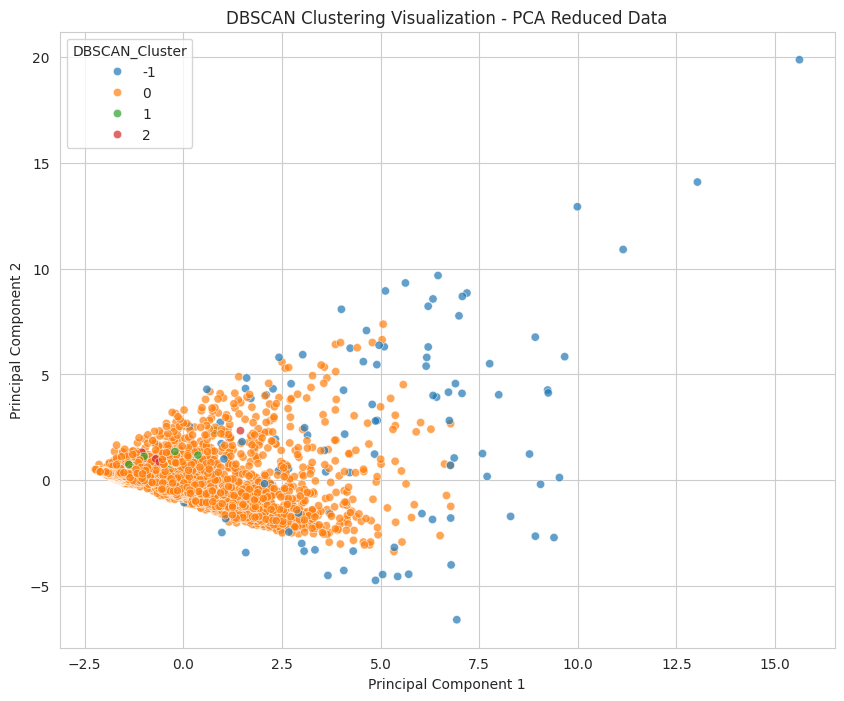

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# For visualization, reduce dimensions using PCA to 2 components
pca = PCA(n_components=2)
df_pca = pca.fit_transform(scaled_df)

# Create a DataFrame for the PCA results with DBSCAN cluster labels
df_pca_dbscan = pd.DataFrame(data=df_pca, columns=['PCA1', 'PCA2'])
df_pca_dbscan['DBSCAN_Cluster'] = clusters_dbscan

# Plot the DBSCAN clusters (handling noise points, labeled as -1)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='DBSCAN_Cluster',
    data=df_pca_dbscan,
    palette='tab10', # Using 'tab10' for more distinct colors, especially with noise (-1)
    legend='full',
    alpha=0.7
)
plt.title('DBSCAN Clustering Visualization - PCA Reduced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [35]:
# Analyze the characteristics of each DBSCAN cluster (excluding noise -1)
print("\nDBSCAN Cluster Characteristics (Mean Values, excluding noise):")
display(df_clustered_dbscan[df_clustered_dbscan['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster').mean())


DBSCAN Cluster Characteristics (Mean Values, excluding noise):


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
DBSCAN_Cluster,,,,,,,,,,,
0,69064.873997,105.100129,2.047348,1.0,1.0,16058.082536,11.117982,352.867529,1.090298,4101.050712,0.360673
1,39644.434783,0.000000,1.000000,2.0,1.0,8962.478261,13.739130,221.739130,0.782609,3846.304348,0.304348
2,41562.307692,0.000000,1.000000,3.0,1.0,16338.230769,16.076923,323.076923,0.923077,4133.384615,0.307692


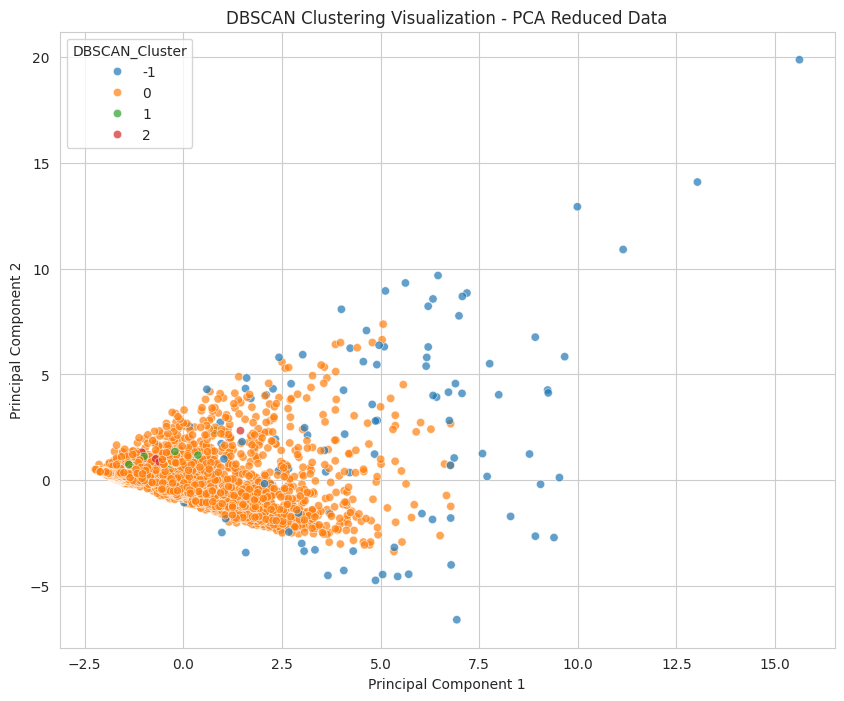

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Ensure clusters_dbscan is defined by taking the best result from previous steps
clusters_dbscan = best_clusters_dbscan

# For visualization, reduce dimensions using PCA to 2 components
pca = PCA(n_components=2)
df_pca = pca.fit_transform(scaled_df)

# Create a DataFrame for the PCA results with DBSCAN cluster labels
df_pca_dbscan = pd.DataFrame(data=df_pca, columns=['PCA1', 'PCA2'])
df_pca_dbscan['DBSCAN_Cluster'] = clusters_dbscan

# Plot the DBSCAN clusters (handling noise points, labeled as -1)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='DBSCAN_Cluster',
    data=df_pca_dbscan,
    palette='tab10', # Using 'tab10' for more distinct colors, especially with noise (-1)
    legend='full',
    alpha=0.7
)
plt.title('DBSCAN Clustering Visualization - PCA Reduced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [37]:
# Analyze the characteristics of each DBSCAN cluster (excluding noise -1)
print("\nDBSCAN Cluster Characteristics (Mean Values, excluding noise):")
display(df_clustered_dbscan[df_clustered_dbscan['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster').mean())


DBSCAN Cluster Characteristics (Mean Values, excluding noise):


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
DBSCAN_Cluster,,,,,,,,,,,
0,69064.873997,105.100129,2.047348,1.0,1.0,16058.082536,11.117982,352.867529,1.090298,4101.050712,0.360673
1,39644.434783,0.000000,1.000000,2.0,1.0,8962.478261,13.739130,221.739130,0.782609,3846.304348,0.304348
2,41562.307692,0.000000,1.000000,3.0,1.0,16338.230769,16.076923,323.076923,0.923077,4133.384615,0.307692


In [36]:
# Analyze the characteristics of each Hierarchical cluster
print("\nHierarchical Clustering Cluster Characteristics (Mean Values):")
display(df_clustered_hc.groupby('HC_Cluster').mean())

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# Experiment with DBSCAN parameters
# A common approach for selecting epsilon is to plot the k-distance graph
# for now, we'll try some common values, usually determined empirically or through prior knowledge

# Let's start with a few combinations. Min_samples is often chosen as 2*dimensions of data or more.
# For our 11 features, 2*11=22, let's try something like 20, 30, 40.
# Epsilon (eps) can be trickier, often determined by plotting k-distance graph. We'll try some values.

eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]
min_samples_values = [5, 10, 15, 20]

best_sil_score_dbscan = -1
best_params_dbscan = None
best_clusters_dbscan = None

print("DBSCAN Parameter Tuning and Silhouette Scores:")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
        clusters_dbscan = dbscan_model.fit_predict(scaled_df)

        # Number of clusters found (excluding noise, which is -1)
        n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
        n_noise = list(clusters_dbscan).count(-1)

        if n_clusters > 1: # Silhouette score requires at least 2 clusters
            sil_score_dbscan = silhouette_score(scaled_df, clusters_dbscan)
            print(f"  eps={eps}, min_samples={min_samples}: Silhouette Score = {sil_score_dbscan:.4f}, Clusters = {n_clusters}, Noise Points = {n_noise}")
            if sil_score_dbscan > best_sil_score_dbscan:
                best_sil_score_dbscan = sil_score_dbscan
                best_params_dbscan = {'eps': eps, 'min_samples': min_samples}
                best_clusters_dbscan = clusters_dbscan
        else:
            print(f"  eps={eps}, min_samples={min_samples}: Not enough clusters (found {n_clusters}) or only noise. Noise Points = {n_noise}")

print(f"\nBest DBSCAN Parameters: {best_params_dbscan}")
print(f"Best DBSCAN Silhouette Score: {best_sil_score_dbscan:.4f}")

# Assign best clusters to a variable for further use
clusters_dbscan = best_clusters_dbscan

# Add the cluster assignments to the original (unscaled) DataFrame
df_clustered_dbscan = df.copy()
df_clustered_dbscan['DBSCAN_Cluster'] = clusters_dbscan

# Display the count of data points per cluster
print("\nDBSCAN Cluster Distribution (Best Parameters):")
display(df_clustered_dbscan['DBSCAN_Cluster'].value_counts().sort_index())


Hierarchical Clustering Cluster Characteristics (Mean Values):


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
HC_Cluster,,,,,,,,,,,
0,116314.450725,363.839130,3.498551,1.000000,1.035507,37150.356522,18.066667,377.000000,1.150000,4696.888406,0.663043
1,46329.336877,9.028618,1.244072,1.000000,1.000000,4868.112428,6.907604,214.812756,0.673753,3769.337694,0.184383
2,134880.892308,393.323077,2.430769,1.000000,1.000000,36582.169231,29.338462,5915.523077,16.638462,4599.607692,0.753846
3,68876.581395,23.255814,1.139535,2.348837,1.000000,14689.837209,17.534884,582.627907,2.209302,3968.930233,0.395349


DBSCAN Parameter Tuning and Silhouette Scores:
  eps=0.5, min_samples=5: Silhouette Score = -0.0783, Clusters = 16, Noise Points = 1413
  eps=0.5, min_samples=10: Silhouette Score = -0.0984, Clusters = 9, Noise Points = 1722
  eps=0.5, min_samples=15: Silhouette Score = -0.1647, Clusters = 10, Noise Points = 1918
  eps=0.5, min_samples=20: Silhouette Score = -0.1133, Clusters = 5, Noise Points = 2135
  eps=1.0, min_samples=5: Silhouette Score = 0.1985, Clusters = 6, Noise Points = 554
  eps=1.0, min_samples=10: Silhouette Score = 0.2185, Clusters = 3, Noise Points = 675
  eps=1.0, min_samples=15: Silhouette Score = 0.2146, Clusters = 2, Noise Points = 734
  eps=1.0, min_samples=20: Silhouette Score = 0.2124, Clusters = 2, Noise Points = 775
  eps=1.5, min_samples=5: Silhouette Score = 0.2537, Clusters = 5, Noise Points = 310
  eps=1.5, min_samples=10: Silhouette Score = 0.2462, Clusters = 3, Noise Points = 377
  eps=1.5, min_samples=15: Silhouette Score = 0.2413, Clusters = 2, Noise Po

,count
DBSCAN_Cluster,
-1,98
0,3865
1,23
2,13


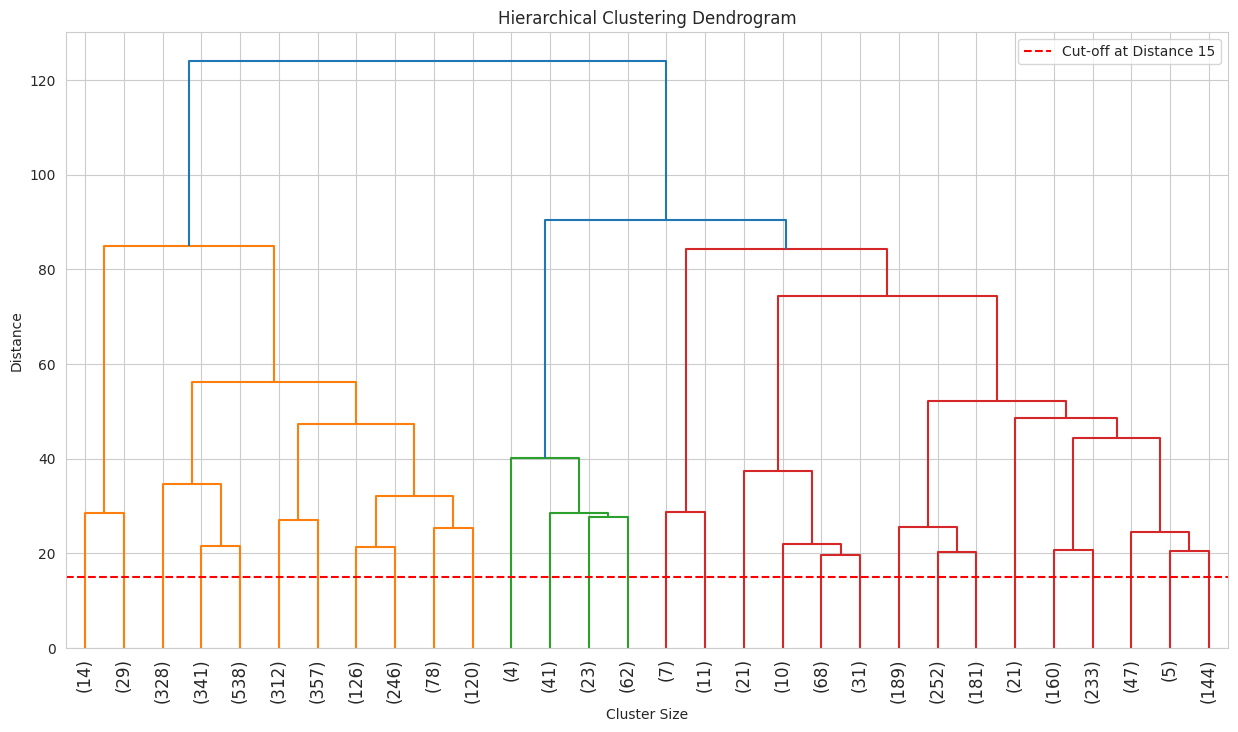

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate the linkage matrix for hierarchical clustering
# 'ward' linkage minimizes the variance of the clusters being merged.
linkage_matrix = linkage(scaled_df, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True, leaf_rotation=90, leaf_font_size=12)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.axhline(y=15, color='r', linestyle='--', label='Cut-off at Distance 15') # Example cut-off
plt.legend()
plt.show()

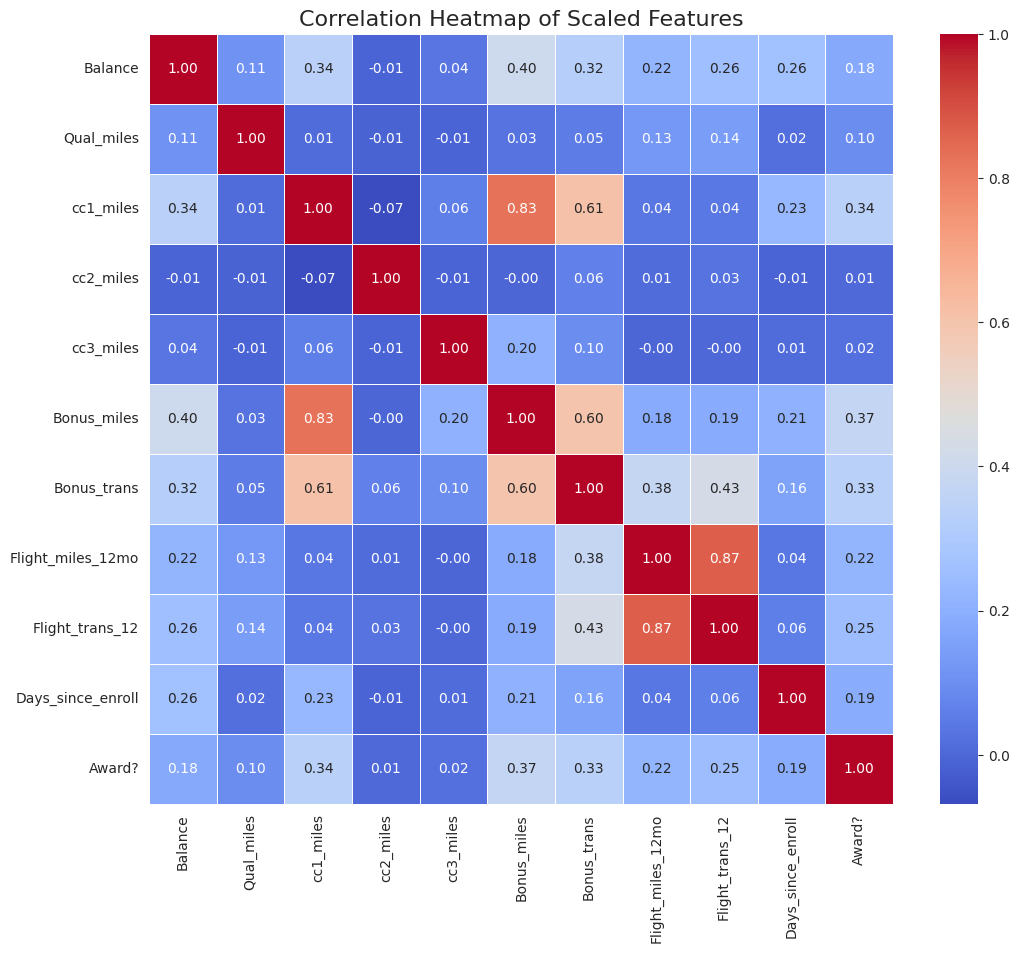

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = scaled_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Scaled Features', fontsize=16)
plt.show()